In [2]:
import importlib
import classical_main as main

importlib.reload(main)

import geometry as geo
import classical_main as main

import numpy as np
import math
import matplotlib.pyplot as plt

def gaussian(r2, sigma):
    value = np.exp( -r2 / (2 * sigma**2) )
    return value

def truncated_gaussian(r2, sigma):
    print()

def wendland_0(r2):
    r = math.sqrt(r2)
    value = ( 1 - r )
    return value


In [ ]:


from scipy.spatial.distance import cdist

def chamfer_cdist(A, B):
    
    distences = cdist(A, B, metric="euclidean")

    min_A_to_B = distences.min(axis=1)
    min_B_to_A = distences.min(axis=0)

    chamfer_distance = min_A_to_B.mean() + min_B_to_A.mean()
    return chamfer_distance


from scipy.spatial import cKDTree

def chamfer_kdtree(points_a, points_b):

    points_a = np.asarray(points_a)
    points_b = np.asarray(points_b)

    tree_a = cKDTree(points_a)
    tree_b = cKDTree(points_b)


    dist_a_to_b, _ = tree_b.query(points_a)
    dist_b_to_a, _ = tree_a.query(points_b)

    return np.mean(dist_a_to_b) + np.mean(dist_b_to_a)


c1, b1 = geo.generate_circle_points()
c2, b2 = geo.generate_square_points()

print(chamfer_cdist(c1, c2))
print(chamfer_kdtree(c1, c2))


0.2818383145322576
0.2818383145322576


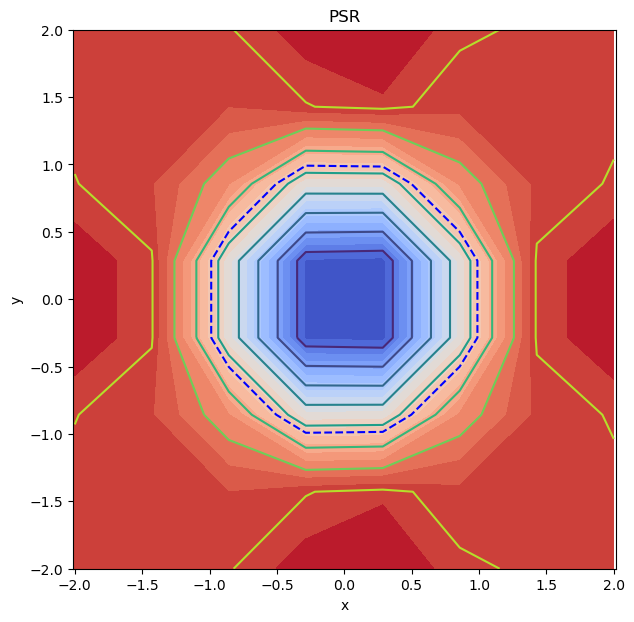

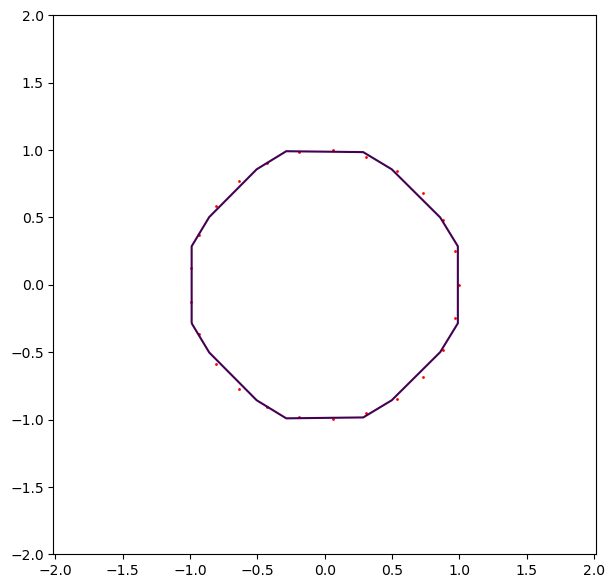

In [15]:

size = 2

nx = 8
ny = 8

x = np.linspace(-size, size, nx)
y = np.linspace(-size, size, ny)

X, Y = np.meshgrid(x, y, indexing="ij")

scan_points, grid_points = geo.generate_circle_points()

chi_grid, iso_value = main.surface_reconstruction(scan_points, grid_points, size, nx, ny, gaussian, 0.1)


plt.figure(figsize=(7, 7))

plt.contour(
    X,
    Y,
    chi_grid,
    levels=[iso_value],
    colors="blue"
)

#plt.scatter(
#    scan_points[:, 0],
#    scan_points[:, 1],
#    color="red",
#    s=50,
#    zorder=3
#)

#plt.quiver(
#    scan_points[:, 0],
#    scan_points[:, 1],    
#    scan_normals[:, 0],
#    scan_normals[:, 1],
#    color="black",
#    angles="xy",
#    scale_units="xy",
#    scale=1,
#    width=0.005,
#    zorder=4
#)

plt.contourf(X, Y, chi_grid, cmap="coolwarm", levels=20)
plt.contour(X, Y, chi_grid)

plt.axis("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title("PSR")

plt.show()



fig, ax = plt.subplots(figsize=(7, 7))

contour = ax.contour(
    X,
    Y,
    chi_grid,
    levels=[iso_value]
)

ax.scatter(
    scan_points[:, 0],
    scan_points[:, 1],
    color="red",
    s=1,
    zorder=1
)

ax.axis("equal")
plt.show()